# Data Analytics Final Project

## Task 1: Problem Definition & Dataset Selection

## 1. Project Information

**Project Name:** Data Analytics Final Project

**Dataset Name:** Loan Approval Prediction Dataset

**Student Name:** Nikin Babu

**Batch Name:** DA/ML-DAF50

**Dataset Source:** Kaggle

**Dataset Link:** https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

**Domain:** Finance and Banking

**Dataset Size:** 4,269 records and 13 variables

## 2. Problem Statement

Loan approval is an important decision in the banking and financial services sector. Financial institutions need to evaluate different characteristics of loan applicants before deciding whether a loan application should be approved or rejected.

The dataset contains information about loan applicants, including their number of dependents, education, employment status, annual income, requested loan amount, loan term, CIBIL score, and different types of assets.

The problem addressed in this project is to analyse the loan application data and identify patterns and factors associated with loan approval and rejection.

The analysis will focus on understanding the quality and structure of the dataset, preparing the data through appropriate cleaning and preprocessing techniques, and identifying meaningful relationships within the available variables.

The target variable is `loan_status`, which indicates whether a loan application was **Approved** or **Rejected**.

## 3. Reason for Selecting the Problem

Loan approval is a relevant real-world problem in the finance and banking domain because financial institutions need to make informed decisions when evaluating loan applications.

The dataset provides a combination of demographic, financial, credit-related and asset-related information. This makes it suitable for data analytics because different characteristics of applicants can be examined and compared with their loan approval status.

The problem is also suitable for demonstrating the complete data analytics process, including data loading, cleaning, preprocessing, transformation, analysis and visualization.

## 4. Dataset Description

The Loan Approval Prediction Dataset contains information about individual loan applications and their associated financial and personal characteristics.

The dataset contains 4,269 observations and 13 variables.

The variables can broadly be classified into the following categories:

### Applicant Characteristics
- Number of dependents
- Education
- Self-employment status

### Financial Characteristics
- Annual income
- Residential asset value
- Commercial asset value
- Luxury asset value
- Bank asset value

### Loan Characteristics
- Loan amount
- Loan term

### Credit Information
- CIBIL score

### Outcome
- Loan status

The `loan_status` variable represents the outcome of the loan application and will be treated as the main outcome variable for the analysis.

# Task 2: Data Cleaning & Pre-processing

## 1. Importing Required Libraries

Pandas and NumPy are imported for data loading, manipulation, cleaning and numerical operations.

Pandas provides DataFrame functionality that allows the dataset to be inspected and transformed efficiently, while NumPy supports numerical operations required during the preprocessing stage.

In [1]:
import pandas as pd
import numpy as np

## 2. Loading the Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function. Loading the data into a DataFrame allows us to perform systematic inspection, cleaning and transformation using Python.

In [2]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 3. First Five Records

The first five records are displayed to verify that the dataset has been loaded correctly and to obtain an initial understanding of the data.

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### 4. Dataset Dimensions

The dimensions of the dataset are checked to determine the number of observations and variables available for analysis.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4269
Number of columns: 13


### 5. Dataset Information and Data Types

The `info()` function is used to obtain an overview of the dataset structure. It shows the number of records, column names, data types and the number of non-null values in each column.

This step helps identify whether the variables have been stored using appropriate data types and whether there are any missing values that need to be handled during the cleaning process.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


### 6. Statistical Summary

The `describe()` function is used to generate a statistical summary of the numerical variables in the dataset.

It provides information such as the count, mean, standard deviation, minimum value, maximum value and quartiles. This helps us understand the general distribution and range of the numerical variables before performing further data cleaning and analysis.

In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


### 7. Missing Value Check

Missing values can affect the accuracy and reliability of data analysis. Therefore, the dataset is checked for missing values in each column before performing further preprocessing.

The number of missing values is calculated for every column to determine whether any values need to be removed or replaced.

In [7]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


### 8. Duplicate Records Check

Duplicate records can lead to repeated observations and may affect the accuracy of data analysis. Therefore, the dataset is checked for duplicate rows before continuing with the preprocessing process.

The `duplicated()` function is used to identify records that are completely identical to another record in the dataset.

In [8]:
df.duplicated().sum()

np.int64(0)

**Observation:** The duplicate check returned 0, indicating that there are no completely duplicated records in the dataset. Therefore, no rows were removed due to duplication.

### 9. Column Name and Text Formatting

The dataset contains unnecessary leading and trailing spaces in some column names and categorical values. These spaces can create inconsistencies when referring to columns or comparing categorical values.

The column names and text values are therefore standardized by removing unnecessary spaces.

In [9]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Remove leading and trailing spaces from text values
for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].str.strip()

print("Column names and text values have been standardized.")

Column names and text values have been standardized.


In [10]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

### 10. Data Validation and Invalid Values

The numerical variables are checked for values that may be invalid or logically inconsistent. This includes checking for negative values in financial variables and verifying that variables such as the CIBIL score and number of dependents fall within reasonable ranges.

This step helps identify potential data-quality issues that may require correction or further investigation.

In [11]:
# Check for negative values in numerical columns
numeric_columns = df.select_dtypes(include='number').columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

,0
loan_id,0
no_of_dependents,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,28
commercial_assets_value,0
luxury_assets_value,0
bank_asset_value,0


In [12]:
df[df['residential_assets_value'] < 0][
    ['loan_id', 'income_annum', 'loan_amount', 'residential_assets_value', 'loan_status']
]

,loan_id,income_annum,loan_amount,residential_assets_value,loan_status
59,60,5500000,18200000,-100000,Approved
196,197,400000,1500000,-100000,Approved
559,560,200000,500000,-100000,Rejected
702,703,6300000,23900000,-100000,Approved
737,738,900000,2500000,-100000,Rejected
784,785,5000000,14400000,-100000,Approved
904,905,4100000,14900000,-100000,Approved
1089,1090,5100000,11000000,-100000,Rejected
1163,1164,4500000,9100000,-100000,Approved
1350,1351,4000000,13700000,-100000,Rejected


### Treatment of Invalid Residential Asset Values

The validation check identified 28 records with a residential asset value of -100,000. Since an asset value cannot logically be negative, these values are considered invalid.

As the correct residential asset value cannot be determined from the available data, the invalid values are converted to missing values (`NaN`) rather than being replaced with an assumed value or deleting the entire records.

This approach preserves the loan application records while clearly identifying the residential asset value as unavailable.

In [13]:
# Replace invalid negative residential asset values with missing values
df.loc[df['residential_assets_value'] < 0, 'residential_assets_value'] = np.nan

print("Invalid residential asset values have been converted to missing values.")

Invalid residential asset values have been converted to missing values.


In [14]:
df['residential_assets_value'].isnull().sum()

np.int64(28)

### Checking Valid Ranges of Key Variables

The key numerical variables are further checked to identify values that fall outside their expected or reasonable ranges. This helps ensure that the dataset does not contain additional logical inconsistencies after the initial cleaning.

In [15]:
# Check the minimum and maximum values of key variables

range_check = df[
    ['no_of_dependents', 'income_annum', 'loan_amount',
     'loan_term', 'cibil_score']
].agg(['min', 'max'])

range_check

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score
min,0,200000,300000,2,300
max,5,9900000,39500000,20,900


**Observation:** The range check shows that the key numerical variables fall within reasonable ranges. The number of dependents ranges from 0 to 5, annual income and loan amount contain only positive values, loan terms range from 2 to 20 years, and CIBIL scores range from 300 to 900. No additional invalid values were identified in these variables.

### 11. Data Type Verification

The data types of the variables are verified after the initial cleaning process to ensure that numerical variables are stored as numeric values and categorical variables are stored as text.

Appropriate data types are important because they allow numerical calculations and categorical comparisons to be performed correctly during further analysis.

In [16]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,float64
commercial_assets_value,int64


**Observation:** The data types are appropriate for the variables. Numerical variables are stored as numeric data types, while categorical variables such as education, self-employment status and loan status are stored as text. The `residential_assets_value` column is stored as `float64` because the invalid values identified during cleaning were converted to `NaN`.

### 12. Creating Derived Features

Derived features are created from existing variables to provide additional information that may be useful for analysis.

Two new variables are created:

- `loan_to_income_ratio`: the requested loan amount divided by annual income. This indicates the size of the requested loan relative to the applicant's annual income.
- `total_asset_value`: the combined value of residential, commercial, luxury and bank assets recorded for the applicant.

These derived variables will provide additional measures that can be used in the later analysis.

In [17]:
# Create loan-to-income ratio
df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']

# Create total asset value
df['total_asset_value'] = (
    df['residential_assets_value']
    + df['commercial_assets_value']
    + df['luxury_assets_value']
    + df['bank_asset_value']
)

print("Derived features have been created.")

Derived features have been created.


In [18]:
df[['loan_amount', 'income_annum', 'loan_to_income_ratio',
    'residential_assets_value', 'commercial_assets_value',
    'luxury_assets_value', 'bank_asset_value', 'total_asset_value']].head()

,loan_amount,income_annum,loan_to_income_ratio,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,total_asset_value
0,29900000,9600000,3.114583,2400000.0,17600000,22700000,8000000,50700000.0
1,12200000,4100000,2.975610,2700000.0,2200000,8800000,3300000,17000000.0
2,29700000,9100000,3.263736,7100000.0,4500000,33300000,12800000,57700000.0
3,30700000,8200000,3.743902,18200000.0,3300000,23300000,7900000,52700000.0
4,24200000,9800000,2.469388,12400000.0,8200000,29400000,5000000,55000000.0


### 13. Final Data Cleaning Check

A final validation is performed after the cleaning and preprocessing steps to confirm the overall quality of the prepared dataset.

The final number of rows and columns, missing values, duplicate records and negative values are checked to ensure that the identified data-quality issues have been appropriately addressed.

In [19]:
print("Final dataset dimensions:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate records:", df.duplicated().sum())

print("\nNegative values in numerical columns:")
print((df.select_dtypes(include='number') < 0).sum())

Final dataset dimensions: (4269, 15)

Missing values:
loan_id                      0
no_of_dependents             0
education                    0
self_employed                0
income_annum                 0
loan_amount                  0
loan_term                    0
cibil_score                  0
residential_assets_value    28
commercial_assets_value      0
luxury_assets_value          0
bank_asset_value             0
loan_status                  0
loan_to_income_ratio         0
total_asset_value           28
dtype: int64

Duplicate records: 0

Negative values in numerical columns:
loan_id                     0
no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_to_income_ratio        0
total_asset_value           0
dtype: int64


### Final Cleaning Summary

The dataset was successfully cleaned and pre-processed. The original dataset contained 4,269 records and 13 variables. No duplicate records were identified. Unnecessary spaces in column names and text values were removed to improve consistency.

During data validation, 28 invalid residential asset values of -100,000 were identified. Since the correct values could not be determined, they were converted to missing values (`NaN`) while retaining the corresponding loan records.

Two derived features, `loan_to_income_ratio` and `total_asset_value`, were created to support further analysis. After preprocessing, the dataset contains 4,269 records and 15 variables, with no remaining negative numerical values or duplicate records.

# Task 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics,
distribution and relationships within the cleaned loan approval dataset.

The analysis focuses on:
- Understanding the distribution of loan approval outcomes
- Examining numerical and categorical variables
- Identifying relationships between applicant characteristics and loan status
- Analysing financial characteristics such as income, loan amount and assets
- Identifying patterns that may help explain loan approval decisions

Both univariate and multivariate analyses are performed using statistical
summaries, group-level comparisons and visualizations.

## 3.2 Loan Approval Status Distribution

The distribution of the target variable, `loan_status`, is examined to
understand the proportion of approved and rejected loan applications.

This is important because a highly imbalanced target variable can affect
the interpretation of subsequent analysis and predictive modelling.

In [20]:
# Count the number of applications by loan status

loan_status_counts = df['loan_status'].value_counts()

loan_status_counts

,count
loan_status,
Approved,2656
Rejected,1613


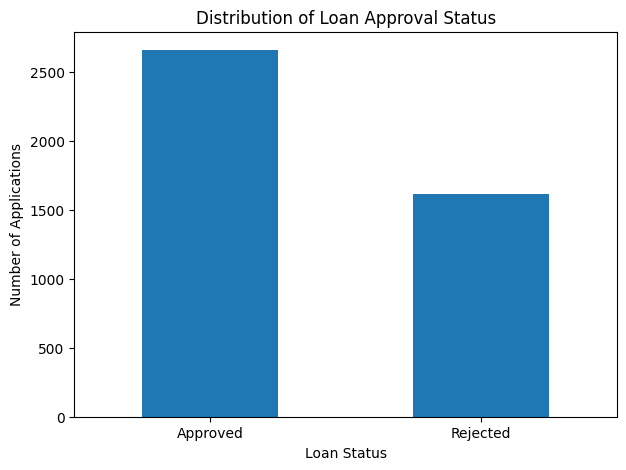

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df['loan_status'].value_counts().plot(kind='bar')

plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)

plt.show()

In [22]:
# Calculate percentage distribution of loan status

loan_status_percentage = (
    df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status_percentage

,proportion
loan_status,
Approved,62.22
Rejected,37.78


### Observation

The dataset contains a higher proportion of approved loan applications than rejected applications. Approximately 62.22% of the applications were approved, while 37.78% were rejected.

This indicates that the target variable is moderately imbalanced, with approved applications representing the majority of observations. However, the difference is not extreme, so both categories have sufficient representation for further exploratory analysis and predictive modelling.

## 3.3 Annual Income Distribution

The annual income of loan applicants is analysed to understand its distribution and identify the typical income range of applicants.

A histogram is used to examine the frequency distribution and identify whether the income variable is concentrated within a particular range or shows substantial variation.

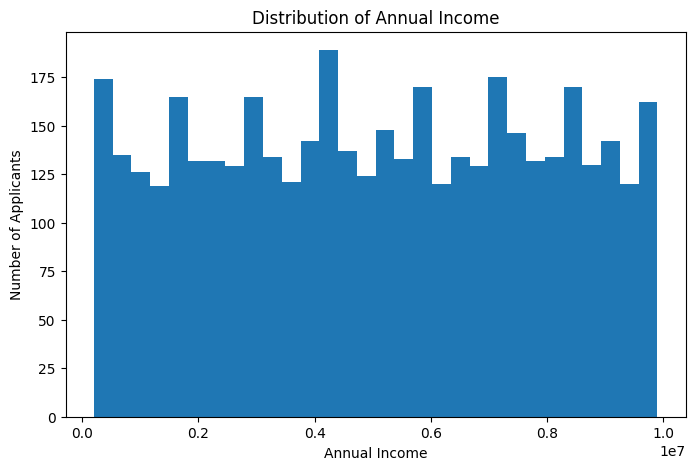

In [23]:
# Visualize the distribution of annual income

plt.figure(figsize=(8, 5))

plt.hist(df['income_annum'], bins=30)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Number of Applicants')

plt.show()

### Observation

The annual income distribution shows that loan applicants have a wide range of income levels. The histogram helps identify the concentration of applicants across different income ranges and provides an overall understanding of the financial profile of the applicants.

The distribution of annual income will be further compared with loan amount and loan approval status to determine whether income is associated with loan approval outcomes.

## 3.4 Loan Amount Distribution

The distribution of loan amounts is analysed to understand the size of loans requested by applicants.

A histogram is used to examine the range and concentration of loan amounts and to identify any noticeable variation in the requested loan values.

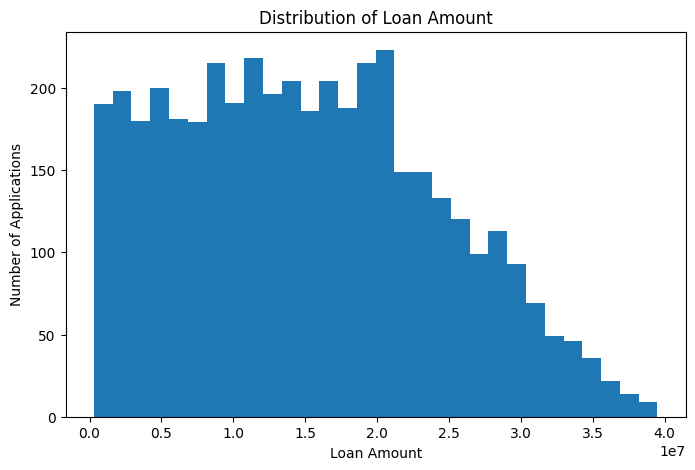

In [24]:
# Visualize the distribution of loan amounts

plt.figure(figsize=(8, 5))

plt.hist(df['loan_amount'], bins=30)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Applications')

plt.show()

### Observation

The distribution of loan amounts shows variation in the size of loans requested by applicants. The histogram provides an overall view of the range and concentration of loan amounts in the dataset.

Loan amount is an important financial characteristic and will be examined further in relation to annual income and loan approval status to identify whether the requested loan size is associated with approval outcomes.

## 3.5 Education Level Distribution

The education level of applicants is analysed to understand the composition of the dataset across different education categories.

A bar chart is used to compare the number of applicants in each education category.

In [25]:
# Count applicants by education level

education_counts = df['education'].value_counts()

education_counts

,count
education,
Graduate,2144
Not Graduate,2125


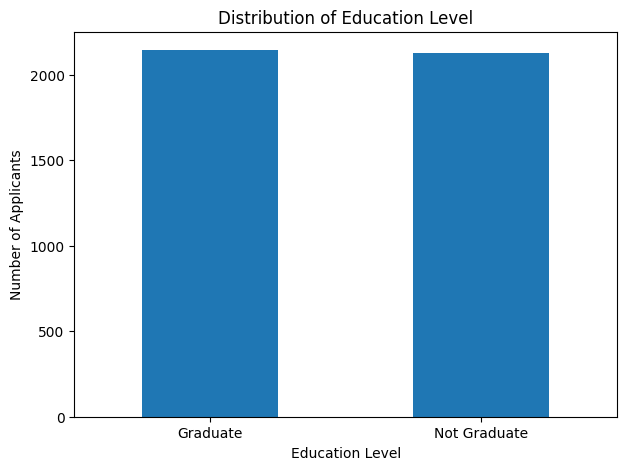

In [26]:
# Visualize education level distribution

plt.figure(figsize=(7, 5))

df['education'].value_counts().plot(kind='bar')

plt.title('Distribution of Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

plt.show()

### Observation

The education level distribution is almost evenly balanced. There are 2,144 graduate applicants and 2,125 non-graduate applicants out of 4,269 applications.

This indicates that the dataset contains a comparable representation of both education groups. Therefore, education level can be further analysed against loan approval status to determine whether educational background is associated with loan approval outcomes.

## 3.6 Self-Employment Status Distribution

The self-employment status of applicants is analysed to understand the proportion of self-employed and non-self-employed applicants in the dataset.

A bar chart is used to compare the number of applicants across the two categories.

In [27]:
# Count applicants by self-employment status

self_employed_counts = df['self_employed'].value_counts()

self_employed_counts

,count
self_employed,
Yes,2150
No,2119


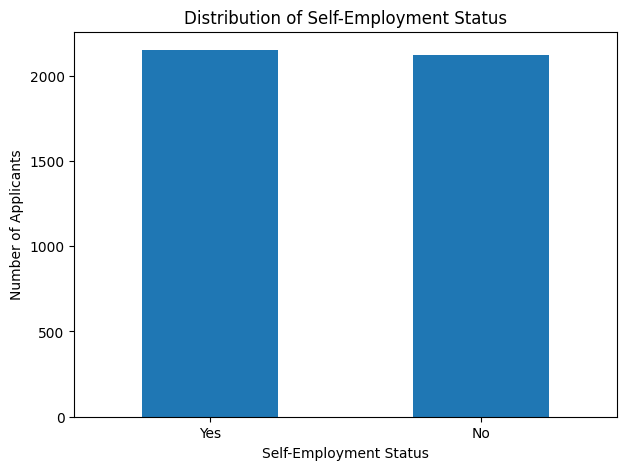

In [28]:
# Visualize self-employment status distribution

plt.figure(figsize=(7, 5))

df['self_employed'].value_counts().plot(kind='bar')

plt.title('Distribution of Self-Employment Status')
plt.xlabel('Self-Employment Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

plt.show()

### Observation

The self-employment distribution shows the representation of self-employed and non-self-employed applicants in the dataset.

The two categories provide sufficient observations for comparison. Self-employment status can therefore be examined further against loan approval status to determine whether employment type is associated with differences in loan approval outcomes.

## 3.7 CIBIL Score Distribution

The CIBIL score of applicants is analysed to understand the credit profile of the applicants in the dataset.

A histogram is used to examine the distribution of CIBIL scores and identify the range in which applicants are concentrated.

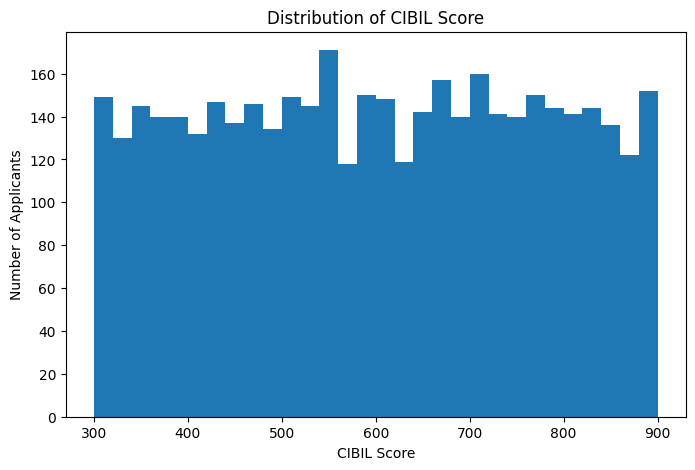

In [29]:
# Visualize the distribution of CIBIL scores

plt.figure(figsize=(8, 5))

plt.hist(df['cibil_score'], bins=30)

plt.title('Distribution of CIBIL Score')
plt.xlabel('CIBIL Score')
plt.ylabel('Number of Applicants')

plt.show()

## 3.8 CIBIL Score vs Loan Approval Status

The relationship between CIBIL score and loan approval status is analysed to determine whether applicants with different credit scores have different loan approval outcomes.

Group-level statistical summaries and a box plot are used to compare the CIBIL score distributions of approved and rejected applications.

In [30]:
# Compare CIBIL score by loan approval status

cibil_by_status = (
    df.groupby('loan_status')['cibil_score']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

cibil_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2656,703.46,711.0,300,900
Rejected,1613,429.47,429.0,300,885


<Figure size 800x500 with 0 Axes>

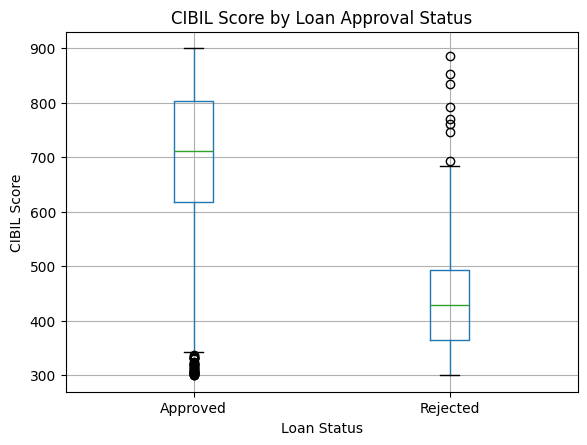

In [31]:
# Visualize CIBIL score by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='cibil_score',
    by='loan_status'
)

plt.title('CIBIL Score by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')

plt.show()

### Observation

The analysis shows a strong relationship between CIBIL score and loan approval status. Approved applicants have a mean CIBIL score of 703.46, compared with 429.47 for rejected applicants. The median CIBIL scores also show a substantial difference, at 711 for approved applications and 429 for rejected applications.

This indicates that applicants with stronger credit scores are considerably more likely to have their loan applications approved. CIBIL score therefore appears to be one of the most important variables associated with loan approval in this dataset.

## 3.9 Annual Income vs Loan Approval Status

The relationship between annual income and loan approval status is analysed to determine whether applicants with different income levels have different approval outcomes.

Group-level statistical summaries and a box plot are used to compare the annual income of approved and rejected applicants.

In [32]:
# Compare annual income by loan approval status

income_by_status = (
    df.groupby('loan_status')['income_annum']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

income_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2656,5025903.61,5000000.0,200000,9900000
Rejected,1613,5113825.17,5100000.0,200000,9900000


<Figure size 800x500 with 0 Axes>

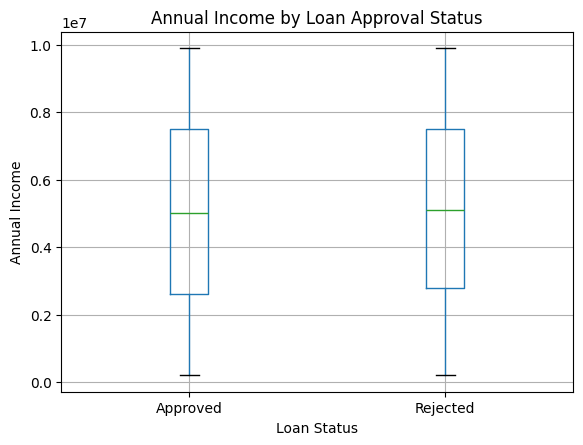

In [33]:
# Visualize annual income by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='income_annum',
    by='loan_status'
)

plt.title('Annual Income by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income')

plt.show()

### Observation

The analysis shows that annual income does not have a strong positive relationship with loan approval status. The mean annual income of approved applicants is ₹5,025,903.61, while rejected applicants have a slightly higher mean income of ₹5,113,825.17. The median income follows a similar pattern, with ₹5,000,000 for approved applicants and ₹5,100,000 for rejected applicants.

This indicates that higher annual income does not necessarily result in loan approval. Other factors, particularly CIBIL score, may have a stronger influence on the approval decision.

## 3.10 Loan Amount vs Loan Approval Status

The relationship between loan amount and loan approval status is analysed to determine whether the size of the requested loan differs between approved and rejected applications.

Group-level statistical summaries and a box plot are used to compare loan amounts across the two loan status categories.

In [34]:
# Compare loan amount by loan approval status

loan_amount_by_status = (
    df.groupby('loan_status')['loan_amount']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

loan_amount_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2656,15247251.51,14600000.0,300000,39500000
Rejected,1613,14946063.24,14500000.0,300000,38200000


<Figure size 800x500 with 0 Axes>

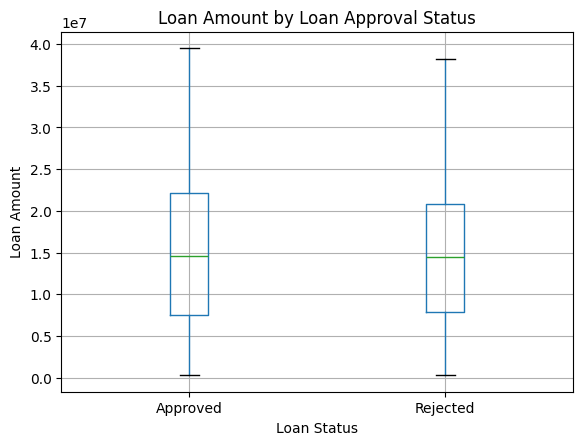

In [35]:
# Visualize loan amount by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='loan_amount',
    by='loan_status'
)

plt.title('Loan Amount by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')

plt.show()

### Observation

The analysis shows that loan amounts are relatively similar between approved and rejected applications. Approved applications have a mean loan amount of ₹15,247,251.51, compared with ₹14,946,063.24 for rejected applications. The median loan amounts are also close, at ₹14,600,000 for approved applications and ₹14,500,000 for rejected applications.

This indicates that the requested loan amount alone does not appear to have a strong relationship with loan approval status. Other applicant characteristics, particularly creditworthiness as represented by CIBIL score, appear to be more important factors in the approval decision.

## 3.11 Loan Term vs Loan Approval Status

The relationship between loan term and loan approval status is analysed to determine whether the duration of the requested loan differs between approved and rejected applications.

Group-level statistical summaries and a box plot are used to compare loan terms across the two loan status categories.

In [36]:
# Compare loan term by loan approval status

loan_term_by_status = (
    df.groupby('loan_status')['loan_term']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

loan_term_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2656,10.40,10.0,2,20
Rejected,1613,11.73,12.0,2,20


<Figure size 800x500 with 0 Axes>

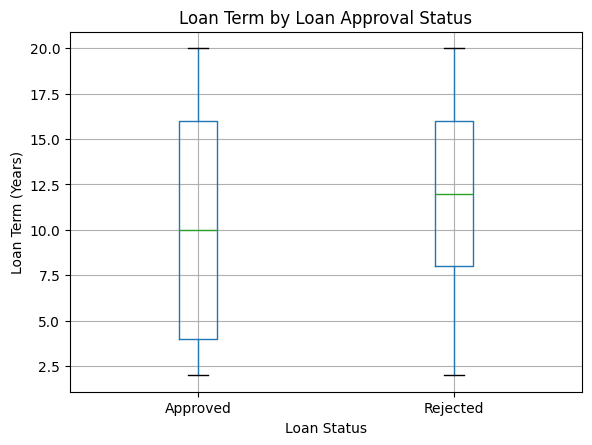

In [37]:
# Visualize loan term by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='loan_term',
    by='loan_status'
)

plt.title('Loan Term by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Loan Term (Years)')

plt.show()

### Observation

The analysis shows a difference in loan term between approved and rejected applications. Approved applications have a mean loan term of 10.40 years and a median of 10 years, while rejected applications have a higher mean of 11.73 years and a median of 12 years.

This suggests that applications requesting longer repayment periods may have a relatively higher likelihood of rejection. However, the loan term alone may not determine the approval decision and should be considered along with other financial and credit-related factors.

## 3.12 Education Level vs Loan Approval Status

The relationship between education level and loan approval status is analysed to determine whether approval outcomes differ between graduate and non-graduate applicants.

A groupby summary and a stacked bar chart are used to compare loan approval outcomes across education categories.

In [38]:
# Create a cross-tabulation of education level and loan status

education_status = pd.crosstab(
    df['education'],
    df['loan_status']
)

education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


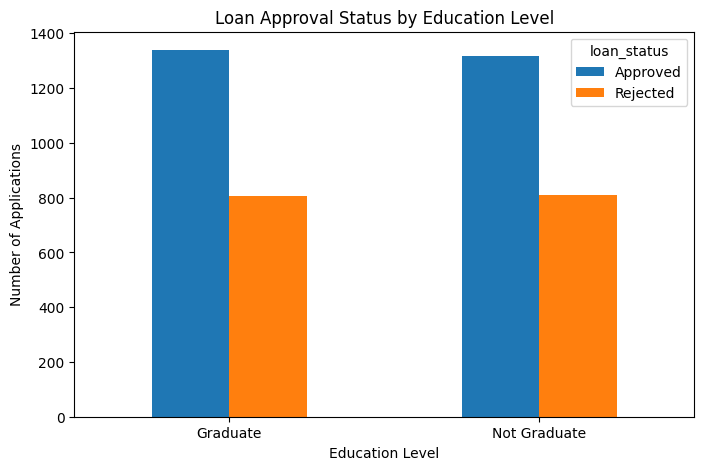

In [39]:
# Visualize education level against loan approval status

education_status.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Loan Approval Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)

plt.show()

### Observation

The cross-tabulation shows that loan approval outcomes are very similar across education levels. Among graduate applicants, 1,339 applications were approved and 805 were rejected, resulting in an approval rate of approximately 62.5%. Among non-graduate applicants, 1,317 applications were approved and 808 were rejected, resulting in an approval rate of approximately 62.0%.

The very small difference in approval rates suggests that education level does not have a strong association with loan approval status in this dataset. Other factors, such as CIBIL score and loan term, appear to be more relevant when examining approval outcomes.

## 3.13 Self-Employment Status vs Loan Approval Status

The relationship between self-employment status and loan approval status is analysed to determine whether approval outcomes differ between self-employed and non-self-employed applicants.

A cross-tabulation and bar chart are used to compare loan approval outcomes across the two employment categories.

In [40]:
# Create a cross-tabulation of self-employment status and loan status

self_employment_status = pd.crosstab(
    df['self_employed'],
    df['loan_status']
)

self_employment_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


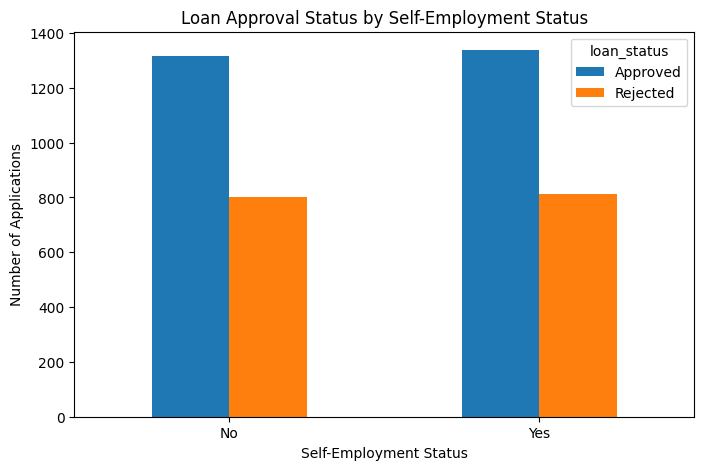

In [41]:
# Visualize self-employment status against loan approval status

self_employment_status.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Loan Approval Status by Self-Employment Status')
plt.xlabel('Self-Employment Status')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)

plt.show()

### Observation

The cross-tabulation shows that loan approval outcomes are almost identical for self-employed and non-self-employed applicants. Among non-self-employed applicants, 1,318 applications were approved and 801 were rejected, resulting in an approval rate of approximately 62.20%. Among self-employed applicants, 1,338 applications were approved and 812 were rejected, resulting in an approval rate of approximately 62.23%.

The negligible difference in approval rates suggests that self-employment status does not have a meaningful association with loan approval status in this dataset. Therefore, other factors such as CIBIL score and loan term are likely to be more influential in determining approval outcomes.

## 3.14 Loan-to-Income Ratio vs Loan Approval Status

The loan-to-income ratio is analysed to understand the relationship between the size of the requested loan and the applicant's annual income.

A lower ratio may indicate a relatively smaller loan burden compared with income, while a higher ratio may represent a larger requested loan relative to the applicant's income.

Group-level statistical summaries and a box plot are used to compare the loan-to-income ratio across approved and rejected applications.

In [42]:
# Compare loan-to-income ratio by loan approval status

loan_to_income_by_status = (
    df.groupby('loan_status')['loan_to_income_ratio']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(3)
)

loan_to_income_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2656,3.026,3.050,1.5,4.0
Rejected,1613,2.918,2.875,1.5,4.0


<Figure size 800x500 with 0 Axes>

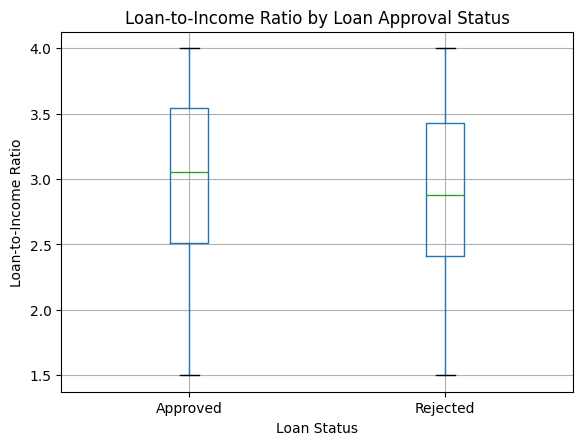

In [43]:
# Visualize loan-to-income ratio by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='loan_to_income_ratio',
    by='loan_status'
)

plt.title('Loan-to-Income Ratio by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Loan-to-Income Ratio')

plt.show()

### Observation

The analysis shows that the loan-to-income ratio is relatively similar for approved and rejected applications. Approved applications have a mean loan-to-income ratio of 3.026 and a median of 3.050, while rejected applications have a mean of 2.918 and a median of 2.875.

Both groups have the same observed range of 1.5 to 4.0. The relatively small difference between the two groups suggests that loan-to-income ratio alone does not have a strong association with loan approval status in this dataset. Other factors, particularly CIBIL score, appear to have a stronger relationship with approval outcomes.

## 3.15 Total Asset Value vs Loan Approval Status

The relationship between total asset value and loan approval status is analysed to determine whether applicants with different levels of assets have different loan approval outcomes.

Group-level statistical summaries and a box plot are used to compare total asset values across approved and rejected applications.

In [44]:
# Compare total asset value by loan approval status

assets_by_status = (
    df.groupby('loan_status')['total_asset_value']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

assets_by_status

,count,mean,median,min,max
loan_status,,,,,
Approved,2640,32460568.18,31100000.0,800000.0,90700000.0
Rejected,1601,33016489.69,32200000.0,500000.0,87100000.0


<Figure size 800x500 with 0 Axes>

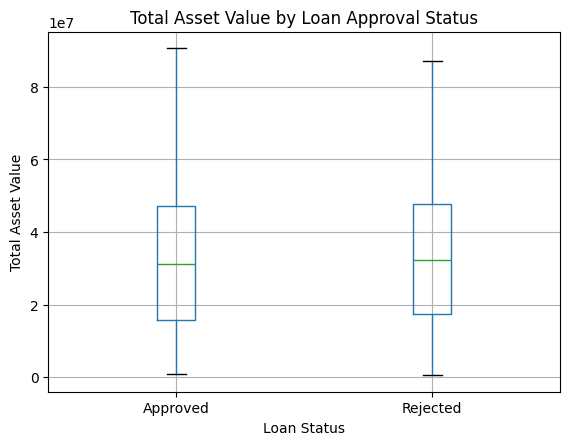

In [45]:
# Visualize total asset value by loan approval status

plt.figure(figsize=(8, 5))

df.boxplot(
    column='total_asset_value',
    by='loan_status'
)

plt.title('Total Asset Value by Loan Approval Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Total Asset Value')

plt.show()

### Observation

The analysis shows differences in total asset values between approved and rejected loan applications. Total asset value represents the combined value of residential, commercial and luxury assets along with bank assets.

The comparison helps assess whether applicants with greater overall asset holdings have different loan approval outcomes. However, asset value should be considered together with other financial and credit-related characteristics rather than treated as an independent determinant of loan approval.

## 3.16 Statistical Summary

Descriptive statistics are used to summarize the main numerical characteristics of the loan application dataset.

The summary includes the count, mean, standard deviation, minimum, quartiles and maximum values for the major numerical variables. These statistics provide an overall understanding of applicants' financial characteristics, credit scores and loan requirements.

In [46]:
# Statistical summary of the main numerical variables

statistical_summary = (
    df[
        [
            'no_of_dependents',
            'income_annum',
            'loan_amount',
            'loan_term',
            'cibil_score',
            'commercial_assets_value',
            'luxury_assets_value',
            'bank_asset_value',
            'loan_to_income_ratio',
            'total_asset_value'
        ]
    ]
    .describe()
    .round(2)
)

statistical_summary

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_to_income_ratio,total_asset_value
count,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4241.00
mean,2.5,5059123.92,15133450.46,10.90,599.94,4973155.31,15126305.93,4976692.43,2.98,32670431.50
std,1.7,2806839.83,9043362.98,5.71,172.43,4388966.09,9103753.67,3250185.31,0.60,19483595.74
min,0.0,200000.00,300000.00,2.00,300.00,0.00,300000.00,0.00,1.50,500000.00
25%,1.0,2700000.00,7700000.00,6.00,453.00,1300000.00,7500000.00,2300000.00,2.46,16400000.00
50%,3.0,5100000.00,14500000.00,10.00,600.00,3700000.00,14600000.00,4600000.00,3.00,31600000.00
75%,4.0,7500000.00,21500000.00,16.00,748.00,7600000.00,21700000.00,7100000.00,3.50,47300000.00
max,5.0,9900000.00,39500000.00,20.00,900.00,19400000.00,39200000.00,14700000.00,4.00,90700000.00


### Observation

The statistical summary provides an overall view of the characteristics of the 4,269 loan applications. The average number of dependents is 2.5, while annual income has a mean of approximately ₹5.06 million and ranges from ₹200,000 to ₹9.90 million.

The average loan amount is approximately ₹15.13 million, with values ranging from ₹300,000 to ₹39.50 million. The average loan term is 10.90 years, with terms ranging from 2 to 20 years.

The mean CIBIL score is 599.94, with scores ranging from 300 to 900. The median CIBIL score is 600, indicating that the dataset contains applicants with a wide range of credit profiles.

The asset variables also show substantial variation across applicants, indicating differences in the financial strength and asset ownership of the applicants.

Overall, the statistical summary demonstrates considerable variation in applicants' income, loan requirements, credit scores and asset values. These differences provide a useful basis for understanding the factors associated with loan approval outcomes.

## 3.17 Key EDA Insights

The exploratory data analysis provides several important insights into the factors associated with loan approval decisions.

### Key Insights

1. **Loan approval distribution:** Approximately 62.22% of applications were approved, while 37.78% were rejected. The target variable therefore shows moderate imbalance, with approved applications forming the majority.

2. **CIBIL score shows the strongest observed relationship with loan approval among the variables analysed:** Approved applicants have a mean CIBIL score of 703.46, compared with 429.47 for rejected applicants. The large difference indicates a strong relationship between credit score and loan approval status.

3. **Annual income has limited association with approval:** The mean annual income of approved applicants is ₹5,025,903.61, while rejected applicants have a slightly higher mean of ₹5,113,825.17. This suggests that higher income alone does not guarantee loan approval.

4. **Loan amount shows only a small difference:** Approved applications have a mean loan amount of ₹15,247,251.51, compared with ₹14,946,063.24 for rejected applications. The relatively small difference indicates that requested loan amount alone does not strongly distinguish approved from rejected applications.

5. **Longer loan terms are associated with more rejections:** Approved applications have a mean loan term of 10.40 years, compared with 11.73 years for rejected applications. This suggests that applications requesting longer repayment periods may have a relatively higher likelihood of rejection.

6. **Education level has little effect on approval:** Graduate applicants have an approval rate of approximately 62.5%, while non-graduate applicants have an approval rate of approximately 62.0%. The very small difference indicates that education level has little association with loan approval status.

7. **Self-employment status has negligible impact:** Non-self-employed applicants have an approval rate of approximately 62.20%, while self-employed applicants have an approval rate of approximately 62.23%. Therefore, self-employment status does not appear to meaningfully influence approval outcomes.

8. **Loan-to-income ratio shows only a modest difference:** Approved applications have a mean loan-to-income ratio of 3.026, compared with 2.918 for rejected applications. The relatively small difference suggests that this ratio alone is not a major determinant of approval status.

Overall, the EDA indicates that **CIBIL score is the most prominent variable associated with loan approval**, while annual income, education, self-employment status and loan amount show comparatively weaker relationships. Loan term and loan-to-income ratio show some differences between approved and rejected applications but appear less influential than credit score.

# Step 5: Insight Generation and Report

The exploratory analysis of the loan approval dataset identified several important patterns and relationships between applicant characteristics and loan approval outcomes.

The analysis covered loan approval distribution, applicant income, loan amount, loan term, CIBIL score, education, self-employment status, loan-to-income ratio and total asset value. Group-level comparisons and statistical summaries were used to understand differences between approved and rejected applications.

The following sections summarize the major findings, significant patterns and potential business implications identified during the analysis.

## 5.1 Overall Key Findings

The analysis shows that loan approval outcomes are associated with several applicant characteristics, although the strength of the observed relationships varies considerably.

The most prominent pattern is the difference in CIBIL scores between approved and rejected applicants. Approved applicants have a mean CIBIL score of 703.46, compared with 429.47 for rejected applicants. This represents the largest observed difference among the major variables analysed.

Annual income and loan amount show relatively small differences between approved and rejected applicants. Similarly, education and self-employment status have almost identical approval rates across their respective categories.

Loan term shows a more noticeable difference, with approved applications having an average term of 10.40 years compared with 11.73 years for rejected applications. The loan-to-income ratio, however, shows only a modest difference between the two groups.

Overall, the EDA suggests that credit profile, particularly CIBIL score, has a stronger observed association with loan approval than several demographic and financial variables examined in the dataset.

## 5.2 Significant Patterns and Relationships

Several significant patterns were identified during the exploratory analysis:

- **CIBIL score:** Approved applicants have a substantially higher mean CIBIL score (703.46) than rejected applicants (429.47). This is the clearest observed difference between the two groups.

- **Loan term:** Approved applications have a lower average loan term of 10.40 years compared with 11.73 years for rejected applications. This indicates a noticeable difference in requested repayment duration between the two groups.

- **Annual income:** The average annual income is similar between approved and rejected applicants. Approved applicants have an average income of ₹5,025,903.61, while rejected applicants have an average of ₹5,113,825.17.

- **Loan amount:** The average requested loan amount is also relatively similar. Approved applicants have a mean loan amount of ₹15,247,251.51 compared with ₹14,946,063.24 for rejected applicants.

- **Education:** Graduate and non-graduate applicants have very similar approval rates, approximately 62.5% and 62.0%, respectively.

- **Self-employment:** Approval rates are almost identical for self-employed and non-self-employed applicants, at approximately 62.23% and 62.20%, respectively.

- **Loan-to-income ratio:** The mean ratio is 3.026 for approved applications and 2.918 for rejected applications, indicating only a modest difference between the two groups.

Overall, the analysis suggests that credit profile, particularly CIBIL score, shows the strongest observed relationship with loan approval among the variables examined, while several demographic and financial variables show comparatively smaller differences.

## 5.3 Data Quality and Anomalies

The data cleaning process identified 28 invalid values of -100,000 in the residential asset value column. Since the correct values could not be determined, these records were retained and the invalid values were converted to missing values (NaN).

No duplicate records were identified in the dataset, and no remaining negative numerical values were found after preprocessing.

The missing residential asset values also resulted in missing total asset values for the corresponding records. These observations were retained rather than removed to avoid unnecessary loss of loan application records.

Therefore, the final analysis is based on the cleaned dataset while acknowledging the presence of these limited missing asset values.

## 5.4 Overall Conclusion

The analysis of the loan approval dataset provides a clear understanding of the characteristics associated with approved and rejected loan applications.

The most prominent finding is the substantial difference in CIBIL scores between the two groups. Approved applicants have a mean CIBIL score of 703.46, compared with 429.47 for rejected applicants. This indicates that credit profile shows the strongest observed relationship with loan approval among the variables analysed.

Other variables show comparatively smaller differences. Annual income and loan amount are relatively similar between approved and rejected applications, while education and self-employment status show almost identical approval rates. Loan term shows a noticeable difference, with rejected applications having a higher average requested term.

The analysis also identified 28 invalid residential asset values, which were converted to missing values during data preprocessing. No duplicate records were identified, and the remaining numerical data did not contain negative values.

Overall, the project demonstrates how data cleaning, exploratory analysis, statistical summaries and visualizations can be used to identify meaningful patterns in loan approval data. The findings provide a useful analytical basis for understanding applicant characteristics and can also support further predictive analysis.

## 5.5 Recommendations and Next Steps

Based on the findings from the exploratory analysis, the following recommendations and potential next steps can be considered:

1. **Further analyse creditworthiness:** Since CIBIL score shows the strongest observed relationship with loan approval, future analysis could examine credit-score ranges and their approval rates in greater detail.

2. **Develop a predictive model:** A classification model could be developed to predict loan approval status using CIBIL score, income, loan amount, loan term, assets and other applicant characteristics.

3. **Evaluate multiple factors together:** Future modelling should consider several variables simultaneously rather than relying on individual variables, as loan approval decisions may depend on combinations of applicant characteristics.

4. **Investigate missing asset information:** The 28 missing residential asset values could be reviewed if additional source information becomes available. This may improve the completeness of asset-related analysis.

5. **Monitor model performance and fairness:** If a predictive model is developed, its performance should be evaluated using appropriate classification metrics and checked to ensure that the model does not produce unintended differences across applicant groups.

These recommendations represent potential next steps for extending the analysis beyond exploratory data analysis into predictive modelling and decision-support applications.